## ml_v13 : position 피처 확대 + k_beauty 제거
* Y값: 정규화(평점) × 정규화(log_review_count) → quantile 30/70 (ml_v12 동일)
* k_beauty 9개 + k_beauty_ratio 제거 (importance=0 6개, 나머지도 ml_v12 pruning에서 탈락)
* 신규 position 피처 5개 성분 × 2 = 10개 추가 (tocopheryl_acetate, peptide, panthenol, caffeine, retinol)
* 베이스라인: ml_v12 Test AUC 0.7866 / 목표: 0.80

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from lightgbm import LGBMClassifier
from scipy.stats import randint, uniform
import re, warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

DATA_PATH = r"C:\workspace\finalproject\data\ml_AmazonSephoraUlta.csv"
df_all = pd.read_csv(DATA_PATH, encoding='utf-8-sig', low_memory=False)

df_all['카테고리(중)'] = df_all['카테고리(중)'].str.lower().str.strip()

print(f"전체: {len(df_all)}개")
print(f"플랫폼별:\n{df_all['store_id'].str.split('_').str[0].value_counts().to_string()}")
print(f"\n리뷰수 있음: {df_all['리뷰수'].notna().sum()}개")
print(f"평점 있음:   {df_all['평점'].notna().sum()}개")
print(f"\ntarget_category 분포:\n{df_all['target_category'].value_counts().to_string()}")

전체: 5964개
플랫폼별:
store_id
amazon     2560
sephora    1802
ulta       1602

리뷰수 있음: 5929개
평점 있음:   5929개

target_category 분포:
target_category
skincare     3963
cleansing    1037
suncare       551
masks         413


In [20]:
# ── Y값: 정규화(평점) × 정규화(log_review_count) → 극단 30% 이진분류
# PCA 제거 근거: KMO=0.0001(부적합), Bartlett p=0.55(비유의), 음의 상관
# 복합 지수 = 질(평점) × 양(리뷰수) → 두 변수의 특성을 명시적으로 반영
df_y = df_all[
    df_all['리뷰수'].notna() &
    df_all['평점'].notna() &
    (df_all['평점'] <= 5)
].copy()

log_review             = np.log1p(df_y['리뷰수'])
df_y['y_rating_norm']  = df_y['평점'] / 5.0
df_y['y_review_norm']  = log_review / log_review.max()
df_y['y_composite']    = df_y['y_rating_norm'] * df_y['y_review_norm']

th_lo = df_y['y_composite'].quantile(0.30)
th_hi = df_y['y_composite'].quantile(0.70)
mask  = (df_y['y_composite'] <= th_lo) | (df_y['y_composite'] >= th_hi)
df_y  = df_y[mask].copy()
df_y['target'] = (df_y['y_composite'] >= th_hi).astype(int)

print(f"복합 지수 분포:")
print(f"  비인기 (하위 30%) 임계값: {th_lo:.4f}")
print(f"  인기   (상위 30%) 임계값: {th_hi:.4f}")
print(f"\n학습 데이터: {len(df_y)}개  (긍정={df_y['target'].sum()}, 부정={len(df_y)-df_y['target'].sum()})")
print(f"플랫폼별:\n{df_y['store_id'].str.split('_').str[0].value_counts().to_string()}")

복합 지수 분포:
  비인기 (하위 30%) 임계값: 0.2639
  인기   (상위 30%) 임계값: 0.4533

학습 데이터: 3546개  (긍정=1773, 부정=1773)
플랫폼별:
store_id
amazon     1615
ulta       1006
sephora     925


In [21]:
# ── 피처 생성
ing_cols = [c for c in df_y.columns if c.startswith('성분_')]
df_y['ingredient_text'] = df_y[ing_cols].fillna('').agg(' '.join, axis=1).str.strip()
ing_lower = df_y['ingredient_text'].str.lower()

# 용량(ml)
def extract_ml(s):
    if pd.isna(s): return np.nan
    m = re.search(r'([\d.]+)\s*ml', str(s), re.IGNORECASE)
    if m: return float(m.group(1))
    m = re.search(r'([\d.]+)\s*oz', str(s), re.IGNORECASE)
    if m: return float(m.group(1)) * 29.5735
    return np.nan
df_y['volume_ml'] = df_y['용량'].apply(extract_ml)

# 가격대
price_d = pd.get_dummies(
    pd.cut(df_y['공급가(USD)'], bins=[0,30,71,9999], labels=['low','mid','high']),
    prefix='price'
).astype(int)
df_y = pd.concat([df_y, price_d], axis=1)

# 카테고리(대) 원핫
cat_d = pd.get_dummies(df_y['target_category'], prefix='cat').astype(int)
df_y = pd.concat([df_y, cat_d], axis=1)

# 카테고리(중) 원핫 (n<50 제거)
mid_counts = df_y['카테고리(중)'].value_counts()
valid_mid  = mid_counts[mid_counts >= 50].index
df_y['cat_mid'] = df_y['카테고리(중)'].where(df_y['카테고리(중)'].isin(valid_mid), other='기타')
mid_d = pd.get_dummies(df_y['cat_mid'], prefix='mid').astype(int)
df_y = pd.concat([df_y, mid_d], axis=1)

# K뷰티 성분
kbeauty_map = {
    'k_galactomyces': 'galactomyces', 'k_bifida':      'bifida',
    'k_centella':     'centella',     'k_ginseng':     'ginseng',
    'k_snail':        'snail',        'k_beta_glucan': 'beta-glucan',
    'k_bakuchiol':    'bakuchiol',    'k_pdrn':        'polydeoxyribonucleotide|pdrn',
    'k_propolis':     'propolis',
}
for feat, kw in kbeauty_map.items():
    df_y[feat] = ing_lower.str.contains(kw, regex=True).astype(int)
k_cols = list(kbeauty_map.keys())
df_y['k_beauty_ratio'] = df_y[k_cols].sum(axis=1) / len(k_cols)

# US 트렌드 성분 20개 (EDA 기반)
gt_map = {
    'gt_tocopherol':        'tocopherol',
    'gt_tocopheryl_acetate':'tocopheryl acetate',
    'gt_sodium_hyaluronate':'sodium hyaluronate',
    'gt_niacinamide':       'niacinamide',
    'gt_ceramide':          'ceramide',
    'gt_panthenol':         'panthenol',
    'gt_caprylic':          'caprylic',
    'gt_pdrn':              'polydeoxyribonucleotide',
    'gt_exosome':           'exosome',
    'gt_nad':               'nicotinamide adenine',
    'gt_bakuchiol':         'bakuchiol',
    'gt_azelaic_acid':      'azelaic acid',
    'gt_tranexamic_acid':   'tranexamic acid',
    'gt_vitamin_c':         'ascorbic',
    'gt_ectoin':            'ectoin',
    'gt_centella_asiatica': 'centella asiatica',
    'gt_peptide':           'peptide',
    'gt_squalane':          'squalane',
    'gt_caffeine':          'caffeine',
    'gt_retinol':           'retinol',
}
for feat, kw in gt_map.items():
    df_y[feat] = ing_lower.str.contains(kw, regex=True).astype(int)
gt_cols = list(gt_map.keys())
df_y['us_trend_ratio'] = df_y[gt_cols].sum(axis=1) / len(gt_cols)

print("피처 생성 완료")
print(f"카테고리(중) 유효 범주 (n≥50): {valid_mid.tolist()}")
print(f"\nGT 성분 커버리지:")
for c in gt_cols:
    print(f"  {c}: {df_y[c].mean()*100:.1f}%")

피처 생성 완료
카테고리(중) 유효 범주 (n≥50): ['cream', 'cleansing foam/gel', 'essence/serum/ampoule', 'moisturizers', 'sun cream', 'treatments', 'cleansers', 'eye care', 'wash-off pack', 'masks', 'skin/toner']

GT 성분 커버리지:
  gt_tocopherol: 0.1%
  gt_tocopheryl_acetate: 14.2%
  gt_sodium_hyaluronate: 34.0%
  gt_niacinamide: 15.3%
  gt_ceramide: 9.2%
  gt_panthenol: 12.0%
  gt_caprylic: 0.0%
  gt_pdrn: 0.0%
  gt_exosome: 0.0%
  gt_nad: 0.0%
  gt_bakuchiol: 1.0%
  gt_azelaic_acid: 0.7%
  gt_tranexamic_acid: 0.4%
  gt_vitamin_c: 7.8%
  gt_ectoin: 0.0%
  gt_centella_asiatica: 3.7%
  gt_peptide: 14.6%
  gt_squalane: 0.0%
  gt_caffeine: 7.3%
  gt_retinol: 6.2%


In [22]:
# ── 신규 성분 Position 피처 계산 (5개 성분 × 2 = 10 피처)
ing_cols_p = [c for c in df_y.columns if c.startswith('성분_')]
total_ing_count = df_y[ing_cols_p].notna().sum(axis=1).clip(lower=1)

new_position_targets = {
    'tocopheryl_acetate': 'tocopheryl acetate',
    'peptide':            'peptide',
    'panthenol':          'panthenol',
    'caffeine':           'caffeine',
    'retinol':            'retinol',
}

def find_first_idx(row, pattern):
    for i, v in enumerate(row):
        if pd.notna(v) and pattern in str(v).lower():
            return i
    return -1

# phenoxyethanol 인덱스 (1% 기준 프록시) — 한 번만 계산
pheno_idx_s = df_y[ing_cols_p].apply(
    lambda row: find_first_idx(row, 'phenoxyethanol'), axis=1
)

new_pos_cols = []
for feat, pattern in new_position_targets.items():
    idx_s = df_y[ing_cols_p].apply(
        lambda row, p=pattern: find_first_idx(row, p), axis=1
    )
    pos_col = f'{feat}_position'
    abv_col = f'{feat}_above_1pct'

    df_y[pos_col] = np.where(idx_s >= 0, 1 - idx_s / total_ing_count, -1)
    df_y[abv_col] = np.where(
        (idx_s >= 0) & (pheno_idx_s >= 0),
        (idx_s < pheno_idx_s).astype(int),
        -1
    )
    new_pos_cols += [pos_col, abv_col]

print(f"신규 Position 피처 {len(new_pos_cols)}개 생성 완료")
for c in new_pos_cols:
    cov = (df_y[c] >= 0).mean() * 100
    print(f"  {c}: 커버리지 {cov:.1f}%")

신규 Position 피처 10개 생성 완료
  tocopheryl_acetate_position: 커버리지 14.2%
  tocopheryl_acetate_above_1pct: 커버리지 0.0%
  peptide_position: 커버리지 14.6%
  peptide_above_1pct: 커버리지 0.0%
  panthenol_position: 커버리지 12.0%
  panthenol_above_1pct: 커버리지 0.0%
  caffeine_position: 커버리지 7.3%
  caffeine_above_1pct: 커버리지 0.0%
  retinol_position: 커버리지 6.2%
  retinol_above_1pct: 커버리지 0.0%


In [23]:
# ── 피처 구성 + Train/Test 분리 (80/20)
from sklearn.model_selection import train_test_split

mid_feat_cols = [c for c in df_y.columns if c.startswith('mid_')]

# 기존 precomp position (CSV에 저장된 것) + 신규 계산 position
precomp_pos_cols = [
    'niacinamide_position', 'niacinamide_above_1pct',
    'ceramide_position',    'ceramide_above_1pct',
    'hyaluronic_acid_position', 'hyaluronic_acid_above_1pct',
    'zinc_oxide_position',  'zinc_oxide_above_1pct',
    'centella_position',    'centella_above_1pct',
    'pdrn_position',        'pdrn_above_1pct',
    'amino_acid_surfactant_position',
    'top5_active_count',    'top30pct_active_count',
    'us_trend_ingredient_position', 'us_trend_ingredient_above_1pct',
]
precomp_pos_cols = [c for c in precomp_pos_cols if c in df_y.columns]
all_pos_cols = precomp_pos_cols + new_pos_cols

feat_cols = (
    ['price_low', 'price_mid', 'price_high']
    + ['volume_ml', 'SPF_Index']
    + [c for c in df_y.columns if c.startswith('cat_') and not c.startswith('cat_mid')]
    + mid_feat_cols
    + gt_cols + ['us_trend_ratio']
    + all_pos_cols
)
feat_cols = [c for c in feat_cols if c in df_y.columns]

X_all = df_y[feat_cols].fillna(0).astype(float).values
y_all = df_y['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42
)

print(f"전체 피처 수: {len(feat_cols)}개  (k_beauty 제거, position +10개)")
print(f"Train: {len(y_train)}개  (긍정={y_train.sum()}, 부정={len(y_train)-y_train.sum()})")
print(f"Test:  {len(y_test)}개   (긍정={y_test.sum()}, 부정={len(y_test)-y_test.sum()})")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_base = cross_validate(LGBMClassifier(random_state=42, verbose=-1),
                          X_train, y_train, cv=skf, scoring=['roc_auc'])['test_roc_auc'].mean()
print(f"\n베이스라인 Train CV AUC: {auc_base:.4f}")

전체 피처 수: 69개  (k_beauty 제거, position +10개)
Train: 2836개  (긍정=1418, 부정=1418)
Test:  710개   (긍정=355, 부정=355)

베이스라인 Train CV AUC: 0.7791


In [24]:
# ── Importance Pruning + 커버리지 5% 미만 GT 제거 (Train 기준)
low_cov = [c for c in gt_cols if df_y[feat_cols][c].mean() < 0.05]
feat_cols_pruned = [c for c in feat_cols if c not in low_cov]
print(f"커버리지 5% 미만 제거 ({len(low_cov)}개): {low_cov}")

# Train에서만 importance 계산
lgbm_full = LGBMClassifier(random_state=42, verbose=-1)
feat_idx = [feat_cols.index(c) for c in feat_cols_pruned]
lgbm_full.fit(X_train[:, feat_idx], y_train)
imp = pd.Series(lgbm_full.feature_importances_, index=feat_cols_pruned)

zero_imp = imp[imp == 0].index.tolist()
feat_cols_pruned = [c for c in feat_cols_pruned if c not in zero_imp]
print(f"Importance=0 제거 ({len(zero_imp)}개): {zero_imp}")
print(f"최종 피처 수: {len(feat_cols_pruned)}개")

# 최종 인덱스로 X 재구성
final_idx = [feat_cols.index(c) for c in feat_cols_pruned]
X_train = X_train[:, final_idx]
X_test  = X_test[:, final_idx]

auc_pruned = cross_validate(LGBMClassifier(random_state=42, verbose=-1),
                            X_train, y_train, cv=skf, scoring=['roc_auc'])['test_roc_auc'].mean()
print(f"\n정제 후 Train CV AUC: {auc_pruned:.4f}")

print("\nTop 20 피처 중요도:")
print(imp[feat_cols_pruned].sort_values(ascending=False).head(20).to_string())

feat_cols = feat_cols_pruned

커버리지 5% 미만 제거 (11개): ['gt_tocopherol', 'gt_caprylic', 'gt_pdrn', 'gt_exosome', 'gt_nad', 'gt_bakuchiol', 'gt_azelaic_acid', 'gt_tranexamic_acid', 'gt_ectoin', 'gt_centella_asiatica', 'gt_squalane']
Importance=0 제거 (10개): ['ceramide_above_1pct', 'zinc_oxide_above_1pct', 'centella_above_1pct', 'pdrn_position', 'pdrn_above_1pct', 'tocopheryl_acetate_above_1pct', 'peptide_above_1pct', 'panthenol_above_1pct', 'caffeine_above_1pct', 'retinol_above_1pct']
최종 피처 수: 48개

정제 후 Train CV AUC: 0.7799

Top 20 피처 중요도:
volume_ml                         452
us_trend_ingredient_position      364
hyaluronic_acid_position          278
niacinamide_position              148
panthenol_position                126
us_trend_ratio                    116
tocopheryl_acetate_position       111
price_low                         105
SPF_Index                          89
peptide_position                   87
caffeine_position                  78
centella_position                  72
mid_cream                          

In [13]:
# ── Optuna 하이퍼파라미터 튜닝 (n_trials=200, TPE 베이지안 탐색)
import optuna
from sklearn.model_selection import cross_val_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 800),
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'num_leaves':        trial.suggest_int('num_leaves', 15, 150),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 60),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'random_state': 42,
        'verbose': -1,
    }
    return cross_val_score(
        LGBMClassifier(**params), X_train, y_train,
        cv=skf, scoring='roc_auc', n_jobs=-1
    ).mean()

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(objective, n_trials=200, show_progress_bar=True)

print(f"최적 Train CV AUC: {study.best_value:.4f}")
print(f"최적 파라미터: {study.best_params}")

  0%|          | 0/200 [00:00<?, ?it/s]

최적 Train CV AUC: 0.7493
최적 파라미터: {'n_estimators': 306, 'max_depth': 11, 'num_leaves': 34, 'learning_rate': 0.020641128111363594, 'min_child_samples': 21, 'subsample': 0.8460765238353306, 'colsample_bytree': 0.5139965191224916, 'reg_alpha': 1.7255083935548871e-06, 'reg_lambda': 4.824809085587614e-08}


In [14]:
# ── Optuna 최적 파라미터로 최종 모델 구성 (downstream 셀 호환용 gs 래퍼)
best_params = {**study.best_params, 'random_state': 42, 'verbose': -1}

class _OptunaResult:
    def __init__(self, params, score):
        self.best_estimator_ = LGBMClassifier(**params)
        self.best_score_ = score

gs = _OptunaResult(best_params, study.best_value)
print(f"Optuna 최적 Train CV AUC : {gs.best_score_:.4f}")
print(f"파라미터 : {best_params}")

Optuna 최적 Train CV AUC : 0.7493
파라미터 : {'n_estimators': 306, 'max_depth': 11, 'num_leaves': 34, 'learning_rate': 0.020641128111363594, 'min_child_samples': 21, 'subsample': 0.8460765238353306, 'colsample_bytree': 0.5139965191224916, 'reg_alpha': 1.7255083935548871e-06, 'reg_lambda': 4.824809085587614e-08, 'random_state': 42, 'verbose': -1}


Train CV AUC : 0.7493
Test AUC     : 0.7446
과적합 갭    : +0.0047

[Train OOF] Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.67      0.68      1418
           1       0.68      0.70      0.69      1418

    accuracy                           0.69      2836
   macro avg       0.69      0.69      0.69      2836
weighted avg       0.69      0.69      0.69      2836

[Test] Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.63      0.67       355
           1       0.67      0.74      0.70       355

    accuracy                           0.69       710
   macro avg       0.69      0.69      0.68       710
weighted avg       0.69      0.69      0.68       710



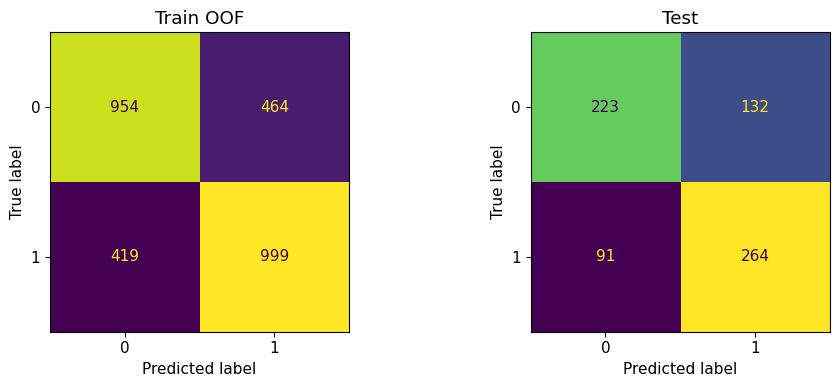

In [15]:
# ── 최종 Test set 평가 (1회만 실행)
from sklearn.model_selection import cross_val_predict

final_model = gs.best_estimator_
final_model.fit(X_train, y_train)

test_auc  = roc_auc_score(y_test, final_model.predict_proba(X_test)[:, 1])
train_auc = gs.best_score_

print(f"Train CV AUC : {train_auc:.4f}")
print(f"Test AUC     : {test_auc:.4f}")
print(f"과적합 갭    : {train_auc - test_auc:+.4f}")

# OOF Confusion Matrix (Train 기준)
y_oof = cross_val_predict(final_model, X_train, y_train, cv=skf, method='predict')
print(f"\n[Train OOF] Classification Report:")
print(classification_report(y_train, y_oof))

# Test Confusion Matrix
print(f"[Test] Classification Report:")
print(classification_report(y_test, final_model.predict(X_test)))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(y_train, y_oof, ax=axes[0], colorbar=False)
axes[0].set_title("Train OOF")
ConfusionMatrixDisplay.from_predictions(y_test, final_model.predict(X_test), ax=axes[1], colorbar=False)
axes[1].set_title("Test")
plt.tight_layout()
plt.show()

In [16]:
# ── 최종 모델 저장
import pickle, os

final_model = gs.best_estimator_
final_model.fit(X_train, y_train)

test_auc = roc_auc_score(y_test, final_model.predict_proba(X_test)[:, 1])
print(f"=== 최종 모델 성능 ===")
print(f"ml_v12 (베이스라인)         : 0.7866")
print(f"ml_v13 (position+k_제거)    : {test_auc:.4f}")
print(f"목표                        : 0.8000")

save_dir = r"C:\workspace\finalproject\data\model_output"
os.makedirs(save_dir, exist_ok=True)

model_data = {
    'model':                 final_model,
    'feat_cols':             feat_cols,
    'gt_map':                gt_map,
    'new_position_targets':  new_position_targets,
    'y_type':                'composite_rating_x_review',
}
save_path = os.path.join(save_dir, 'lgbm_v13.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(model_data, f)

print(f"\n모델 저장 완료: {save_path}")
print(f"저장 피처 수: {len(feat_cols)}개")

=== 최종 모델 성능 ===
ml_v12 (베이스라인)         : 0.7866
ml_v13 (position+k_제거)    : 0.7446
목표                        : 0.8000

모델 저장 완료: C:\workspace\finalproject\data\model_output\lgbm_v13.pkl
저장 피처 수: 49개


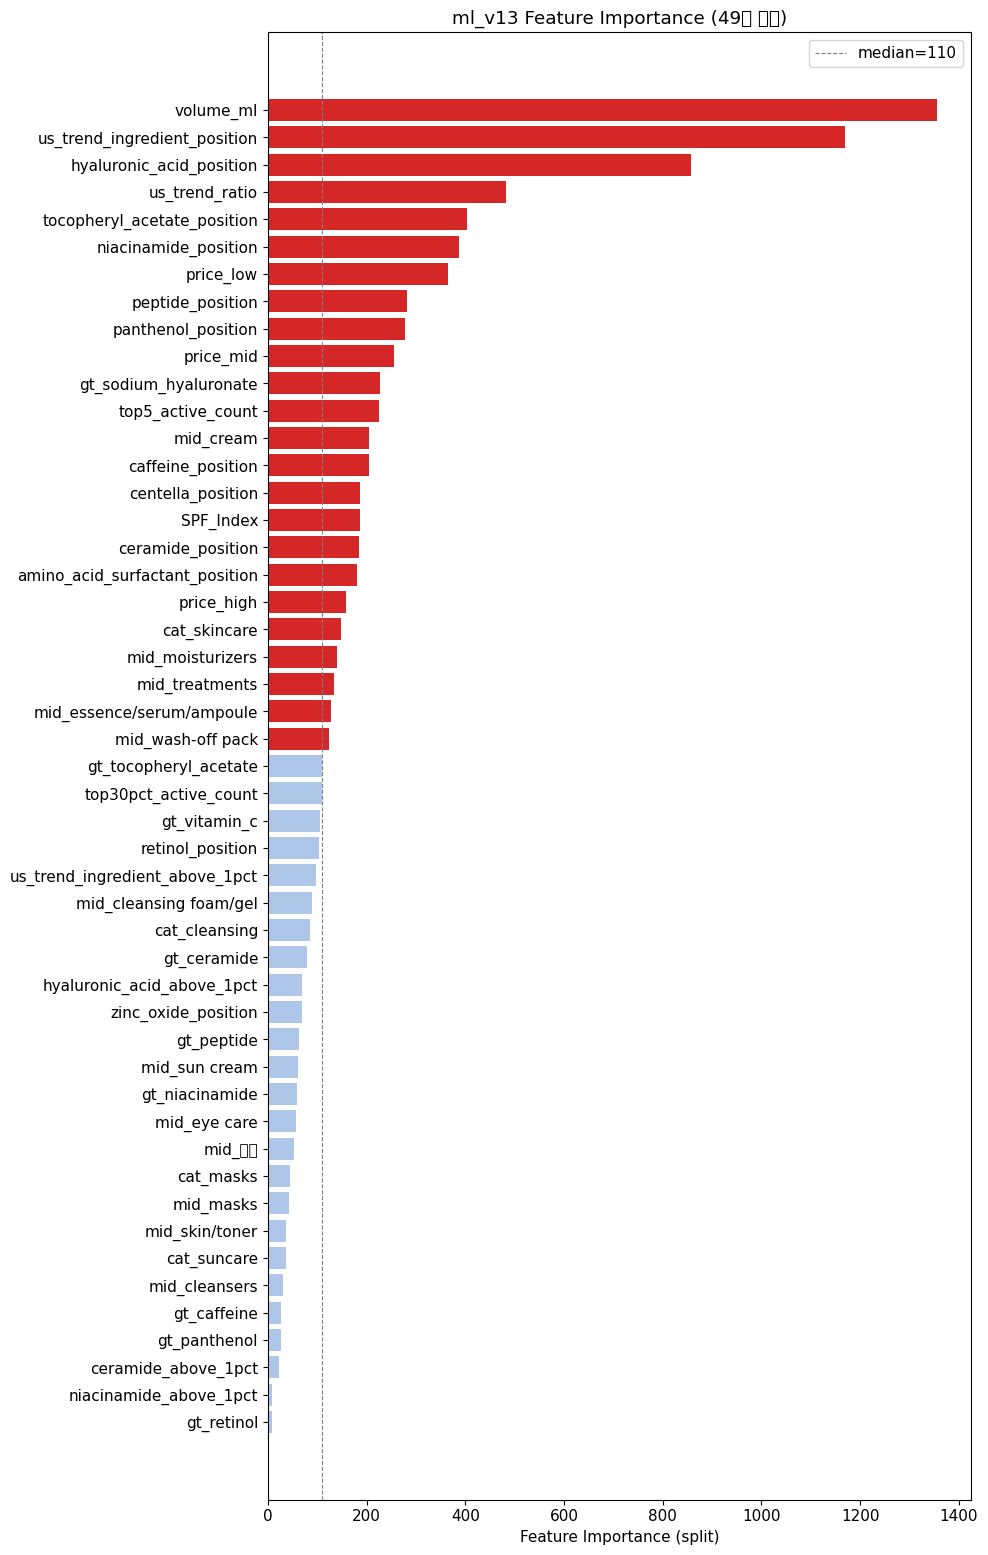


전체 피처 중요도 (내림차순):
volume_ml                         1356
us_trend_ingredient_position      1169
hyaluronic_acid_position           857
us_trend_ratio                     483
tocopheryl_acetate_position        404
niacinamide_position               388
price_low                          365
peptide_position                   282
panthenol_position                 277
price_mid                          255
gt_sodium_hyaluronate              227
top5_active_count                  225
mid_cream                          204
caffeine_position                  204
centella_position                  187
SPF_Index                          186
ceramide_position                  184
amino_acid_surfactant_position     180
price_high                         158
cat_skincare                       148
mid_moisturizers                   140
mid_treatments                     135
mid_essence/serum/ampoule          127
mid_wash-off pack                  124
gt_tocopheryl_acetate              110
top30p

In [17]:
# ── 피처 Importance 시각화
imp_series = pd.Series(final_model.feature_importances_, index=feat_cols).sort_values(ascending=True)

plt.figure(figsize=(10, len(feat_cols) * 0.32))
colors = ['#d62728' if v > imp_series.median() else '#aec7e8' for v in imp_series]
plt.barh(imp_series.index, imp_series.values, color=colors)
plt.axvline(imp_series.median(), color='gray', linestyle='--', linewidth=0.8, label=f'median={imp_series.median():.0f}')
plt.xlabel('Feature Importance (split)')
plt.title(f'ml_v13 Feature Importance ({len(feat_cols)}개 피처)')
plt.legend()
plt.tight_layout()
plt.show()

print("\n전체 피처 중요도 (내림차순):")
print(imp_series.sort_values(ascending=False).to_string())

=== 카테고리별 Test 성능 ===

카테고리                 n      긍정비율      AUC       F1  신뢰도
-----------------------------------------------------------------
skincare           491     48.3%   0.7635   0.6850  ✅ 신뢰
cleansing          114     60.5%   0.6506   0.7500  ✅ 신뢰
masks               46     39.1%   0.7738   0.6842  △ 참고
suncare             59     52.5%   0.6849   0.7250  ✅ 신뢰
-----------------------------------------------------------------
전체                 710     50.0%   0.7446   0.7031


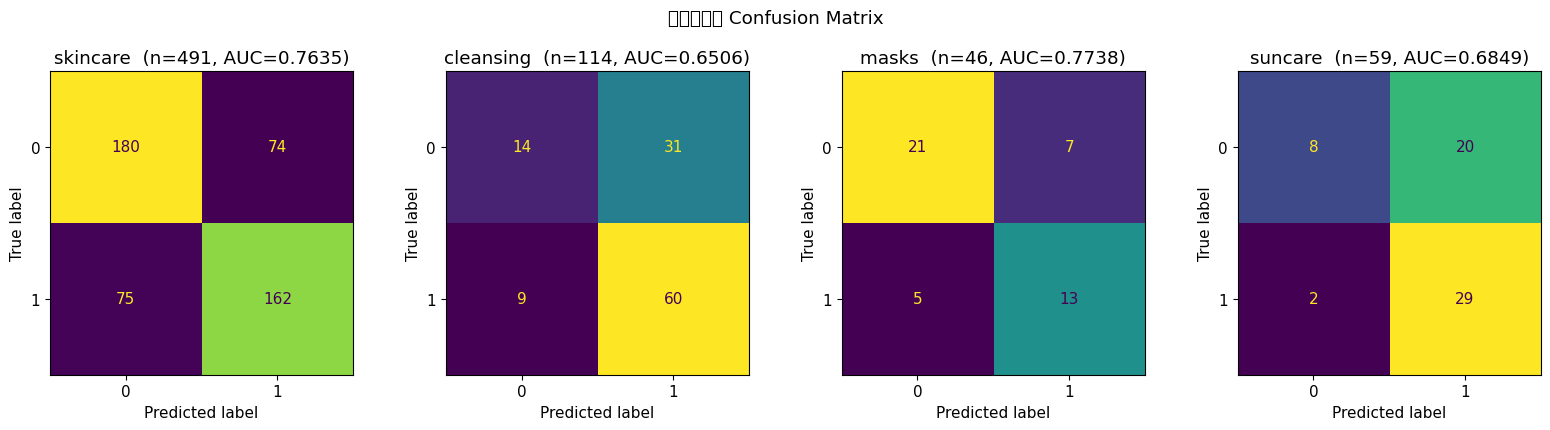

In [18]:
# ── 카테고리별 예측 성능 분석
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split as _tts

# 동일 random_state로 test 인덱스 복원
_indices = np.arange(len(df_y))
_, _test_idx = _tts(_indices, test_size=0.2, stratify=y_all, random_state=42)

test_cats  = df_y['target_category'].iloc[_test_idx].reset_index(drop=True)
test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred  = final_model.predict(X_test)

print("=== 카테고리별 Test 성능 ===\n")
print(f"{'카테고리':<16} {'n':>5}  {'긍정비율':>8}  {'AUC':>7}  {'F1':>7}  신뢰도")
print("-" * 65)

for cat in ['skincare', 'cleansing', 'masks', 'suncare']:
    mask     = (test_cats == cat).values
    n        = mask.sum()
    pos_rate = y_test[mask].mean() if n > 0 else 0

    if n == 0:
        continue
    if len(np.unique(y_test[mask])) < 2 or n < 15:
        print(f"{cat:<16} {n:>5}  {pos_rate:>8.1%}  {'N/A':>7}  {'N/A':>7}  ⚠ 샘플 부족")
        continue

    cat_auc = roc_auc_score(y_test[mask], test_proba[mask])
    cat_f1  = f1_score(y_test[mask], test_pred[mask])
    trust   = "✅ 신뢰" if n >= 50 else "△ 참고"
    print(f"{cat:<16} {n:>5}  {pos_rate:>8.1%}  {cat_auc:>7.4f}  {cat_f1:>7.4f}  {trust}")

print("-" * 65)
print(f"{'전체':<16} {len(y_test):>5}  {y_test.mean():>8.1%}  "
      f"{roc_auc_score(y_test, test_proba):>7.4f}  {f1_score(y_test, test_pred):>7.4f}")

# 카테고리별 Confusion Matrix
cats_to_plot = [c for c in ['skincare', 'cleansing', 'masks', 'suncare']
                if (test_cats == c).sum() >= 15 and len(np.unique(y_test[(test_cats == c).values])) >= 2]
fig, axes = plt.subplots(1, len(cats_to_plot), figsize=(4 * len(cats_to_plot), 4))
if len(cats_to_plot) == 1:
    axes = [axes]
for ax, cat in zip(axes, cats_to_plot):
    mask = (test_cats == cat).values
    auc  = roc_auc_score(y_test[mask], test_proba[mask])
    ConfusionMatrixDisplay.from_predictions(
        y_test[mask], test_pred[mask], ax=ax, colorbar=False
    )
    ax.set_title(f"{cat}  (n={mask.sum()}, AUC={auc:.4f})")
plt.suptitle("카테고리별 Confusion Matrix", y=1.02)
plt.tight_layout()
plt.show()